In [8]:
# =========================================================
# 0) IMPORTS  (keep all imports at the start)
# =========================================================
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

from scipy.stats import qmc
from scipy.spatial.distance import cdist

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [9]:
# =========================================================
# 1) CONFIG  — F1 (Week 06)
# =========================================================
INPUTS_PATH = "data/F1/initial_inputs.npy"
OUTPUTS_PATH = "data/F1/initial_outputs.npy"

# Minimal fallback so the same notebook runs here and on your repo
if not os.path.exists(INPUTS_PATH):
    INPUTS_PATH = os.path.join("/mnt/data", "initial_inputs.npy")
if not os.path.exists(OUTPUTS_PATH):
    OUTPUTS_PATH = os.path.join("/mnt/data", "initial_outputs.npy")

W_EXPLORE = 0.7
W_EXPLOIT = 0.3

N_CANDIDATES = 4096
MIN_DIST = 0.05

SOBOL_SEED = 1
RF_SEED = 0
GP_SEED = 0

GBM_ENSEMBLE_SIZE = 10

In [10]:
# =========================================================
# 2) LOAD  — F1 (Week 06)
# =========================================================
X = np.load(INPUTS_PATH)          # shape (n, 2)
y = np.load(OUTPUTS_PATH).ravel() # shape (n,)

assert X.ndim == 2 and X.shape[1] == 2, f"Expected X shape (n,2), got {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Expected y shape (n,), got {y.shape}"

print("Loaded X:", X.shape, "Loaded y:", y.shape)
print("y stats:", {"min": float(y.min()), "max": float(y.max()), "mean": float(y.mean())})


Loaded X: (15, 2) Loaded y: (15,)
y stats: {'min': -0.010579812589579176, 'max': 6.58252487183483e-10, 'mean': -0.0013280098716931712}


In [11]:
# =========================================================
# 3) SURROGATE  — GP + RF + GBM ensemble
# =========================================================
# Standardise y (important for near-zero regimes)
y_scaler = StandardScaler()
y_std = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

# 3.1 GP (Matérn nu=2.5 + White noise)
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 2.0), nu=2.5)
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-2))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    alpha=0.0,
    n_restarts_optimizer=5,
    random_state=GP_SEED
)
gp.fit(X, y_std)

# 3.2 Random Forest
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=RF_SEED,
    n_jobs=-1
)
rf.fit(X, y_std)

# 3.3 GBM ensemble (different seeds)
gbm_models = []
for rs in range(GBM_ENSEMBLE_SIZE):
    m = GradientBoostingRegressor(
        random_state=rs,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8
    )
    m.fit(X, y_std)
    gbm_models.append(m)

print("Surrogates trained: GP + RF +", len(gbm_models), "GBM models")
print("GP learned kernel:\n", gp.kernel_)



Surrogates trained: GP + RF + 10 GBM models
GP learned kernel:
 0.965**2 * Matern(length_scale=[0.141, 0.0497], nu=2.5) + WhiteKernel(noise_level=0.01)


In [12]:
# =========================================================
# 4) ACQUISITION  — Sobol candidates + min-distance + composite score
# =========================================================
def zscore(v):
    v = np.asarray(v, dtype=float)
    return (v - v.mean()) / (v.std(ddof=1) + 1e-12)

# 4.1 Candidate generation (Sobol over [0,1]^2)
sampler = qmc.Sobol(d=2, scramble=True, seed=SOBOL_SEED)
cand = sampler.random(N_CANDIDATES)

# 4.2 Min-distance filter
dmin = cdist(cand, X).min(axis=1)
cand = cand[dmin > MIN_DIST]
print("Candidates after min-dist filter:", cand.shape[0])

# 4.3 Predictions + uncertainties
# GP
gp_mu, gp_std = gp.predict(cand, return_std=True)

# RF: std over trees
rf_tree_preds = np.stack([t.predict(cand) for t in rf.estimators_], axis=0)
rf_mu = rf_tree_preds.mean(axis=0)
rf_std = rf_tree_preds.std(axis=0, ddof=1)

# GBM ensemble: std over models
gbm_preds = np.stack([m.predict(cand) for m in gbm_models], axis=0)
gbm_mu = gbm_preds.mean(axis=0)
gbm_std = gbm_preds.std(axis=0, ddof=1)

# Ensemble mean (in standardised y-space)
ens_mu = (gp_mu + rf_mu + gbm_mu) / 3.0

# Ensemble uncertainty: average z-scored component uncertainties
ens_sig_z = (zscore(gp_std) + zscore(rf_std) + zscore(gbm_std)) / 3.0

# Exploit term: z-scored mean
ens_mu_z = zscore(ens_mu)

# 4.4 Composite acquisition score
score = W_EXPLORE * ens_sig_z + W_EXPLOIT * ens_mu_z

best_idx = int(np.argmax(score))
x_next = cand[best_idx]

# Predicted y at x_next (back to original scale, optional)
y_next_pred = float(y_scaler.inverse_transform([[ens_mu[best_idx]]]).ravel()[0])

print("NEXT X:", x_next)
print("Predicted y at NEXT X (ensemble mean):", y_next_pred)

# Distance check (to confirm not stuck in one region)
nn_dist = float(np.min(np.linalg.norm(X - x_next.reshape(1, -1), axis=1)))
print("Nearest-neighbour distance of NEXT X:", nn_dist)



Candidates after min-dist filter: 3641
NEXT X: [0.5720216  0.02786129]
Predicted y at NEXT X (ensemble mean): -0.0012034111899208427
Nearest-neighbour distance of NEXT X: 0.20108693526842292


Train R2 (interpret cautiously for sparse near-zero outputs): 0.9645123129497638


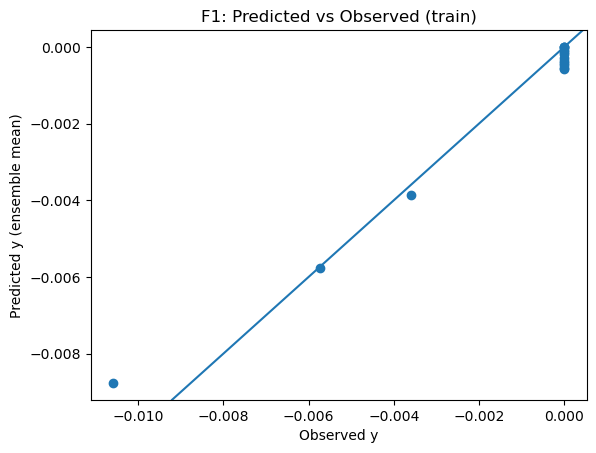

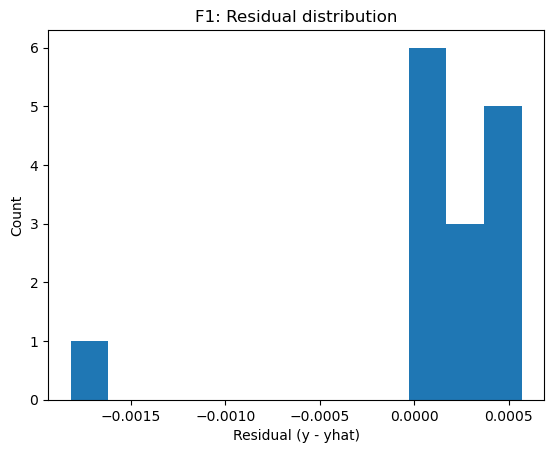

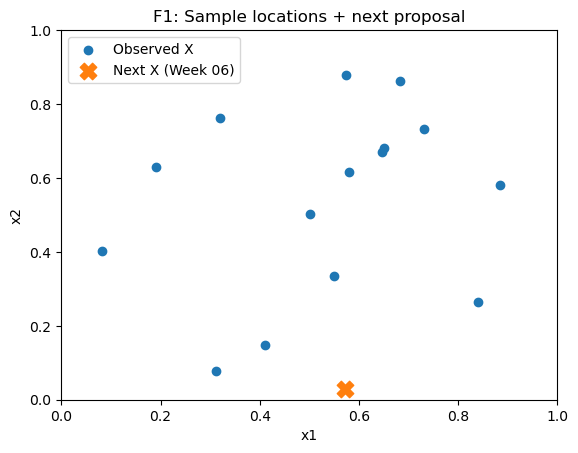

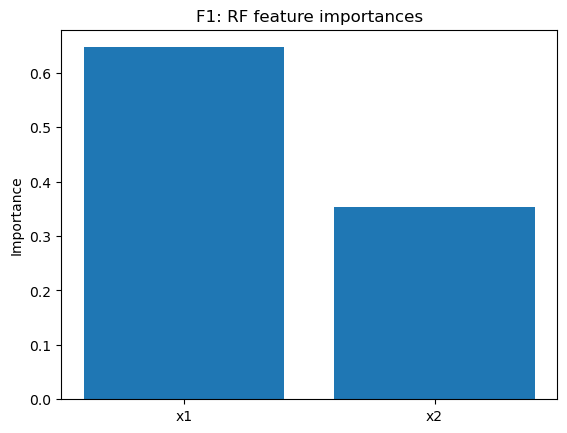

In [13]:
# =========================================================
# 5) DIAGNOSTICS  — mean vs observed, residuals, importances, coverage
# =========================================================
# 5.1 Train predictions (ensemble mean)
gp_mu_tr, _ = gp.predict(X, return_std=True)
rf_mu_tr = np.stack([t.predict(X) for t in rf.estimators_], axis=0).mean(axis=0)
gbm_mu_tr = np.stack([m.predict(X) for m in gbm_models], axis=0).mean(axis=0)
ens_mu_tr = (gp_mu_tr + rf_mu_tr + gbm_mu_tr) / 3.0

yhat_tr = y_scaler.inverse_transform(ens_mu_tr.reshape(-1, 1)).ravel()
resid = y - yhat_tr

print("Train R2 (interpret cautiously for sparse near-zero outputs):", r2_score(y, yhat_tr))

# 5.2 Predicted mean vs observed
plt.figure()
plt.scatter(y, yhat_tr)
plt.xlabel("Observed y")
plt.ylabel("Predicted y (ensemble mean)")
plt.title("F1: Predicted vs Observed (train)")
plt.axline((0, 0), slope=1)
plt.show()

# 5.3 Residuals histogram
plt.figure()
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - yhat)")
plt.ylabel("Count")
plt.title("F1: Residual distribution")
plt.show()

# 5.4 Spatial coverage + next proposal
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Observed X")
plt.scatter([x_next[0]], [x_next[1]], marker="X", s=140, label="Next X (Week 06)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F1: Sample locations + next proposal")
plt.legend()
plt.show()

# 5.5 RF feature importances
plt.figure()
plt.bar(["x1", "x2"], rf.feature_importances_)
plt.ylabel("Importance")
plt.title("F1: RF feature importances")
plt.show()



In [14]:
# =========================================================
# 6) OUTPUT  — one line of values to submit
# =========================================================
print("SUBMIT THIS X ROW:")
print(f"[{x_next[0]:.8f}, {x_next[1]:.8f}]")

SUBMIT THIS X ROW:
[0.57202160, 0.02786129]
